# Experiment 2: Effectiveness Metrics

Compare the 1% poisoning results across EMBER2018 and EMBER2024 Win64, seeds 42/43/44, random and distribution-based sampling, and eight paper selectors. Means and sample standard deviations are calculated across the three master seeds. Extra result folders are audited but excluded.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

def find_root():
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / "configs" / "experiment_2.yaml").is_file():
            return path
    raise FileNotFoundError("Project root not found")

ROOT = find_root()
RESULTS = ROOT / "results" / "experiment 2"
HERE = ROOT / "notebooks" / "experiment_2" / "results"
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
print("Results:", RESULTS)
print("Outputs:", HERE)

Results: /Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 2
Outputs: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_2/results


## Expected Matrix

An asterisk marks a Severi-derived selector. CombinedSHAP uses its matched combined feature/value implementation; the other methods use the fixed LargeAbsSHAP feature selector.

In [2]:
DATASETS = {
    "ember2018": ("EMBER2018", "ember", 1200, 17),
    "ember2024_win64": ("EMBER2024 Win64", "ember2024_win64", 2080, 19),
}
SEEDS = [42, 43, 44]
SAMPLINGS = {
    "random": "Random",
    "distribution_based_distance": "Distribution-based",
}
SELECTORS = [
    ("MinPopulation*", "shap_largest_abs", "min_population_new", "Severi-derived"),
    ("CountAbsSHAP*", "shap_largest_abs", "argmin_Nv_sum_abs_shap", "Severi-derived"),
    ("CombinedSHAP*", "combined_shap", "combined_shap", "Severi-derived"),
    ("FrequencyBoundedSignedSHAP", "shap_largest_abs", "frequency_bounded_signed_shap", "This work"),
    ("CorrCountAbsSHAP", "shap_largest_abs", "corr_count_abs_shap", "This work"),
    ("BenignPrototype", "shap_largest_abs", "benign_prototype", "This work"),
    ("Quantile95", "shap_largest_abs", "quantile_95", "This work"),
    ("LowSHAPSigned", "shap_largest_abs", "low_shap_signed", "This work"),
]
SELECTOR_ORDER = [row[0] for row in SELECTORS]
SAMPLING_ORDER = list(SAMPLINGS.values())
EXPECTED_COUNT = len(DATASETS) * len(SEEDS) * len(SAMPLINGS) * len(SELECTORS)
print("Expected result CSVs:", EXPECTED_COUNT)
display(pd.DataFrame(SELECTORS, columns=["Selector", "Feature selector", "Value selector", "Source"]))

Expected result CSVs: 96


,Selector,Feature selector,Value selector,Source
0,MinPopulation*,shap_largest_abs,min_population_new,Severi-derived
1,CountAbsSHAP*,shap_largest_abs,argmin_Nv_sum_abs_shap,Severi-derived
2,CombinedSHAP*,combined_shap,combined_shap,Severi-derived
3,FrequencyBoundedSignedSHAP,shap_largest_abs,frequency_bounded_signed_shap,This work
4,CorrCountAbsSHAP,shap_largest_abs,corr_count_abs_shap,This work
5,BenignPrototype,shap_largest_abs,benign_prototype,This work
6,Quantile95,shap_largest_abs,quantile_95,This work
7,LowSHAPSigned,shap_largest_abs,low_shap_signed,This work


## Load And Validate

Validation requires one row per CSV, finite effectiveness metrics, the expected poison-row count, and the expected watermark size.

In [3]:
METRICS = [
    "orig_model_orig_test_set_accuracy",
    "new_model_orig_test_set_accuracy",
    "orig_model_mw_test_set_accuracy",
    "new_model_mw_test_set_accuracy",
    "evasions_success_percent",
]

def summary_path(dataset_key, dataset_id, seed, sampling, feature_selector, value_selector):
    experiment = "__".join([
        dataset_id, "lightgbm", feature_selector, value_selector,
        "problem_space_conservative",
    ])
    return (RESULTS / dataset_key / f"seed_{seed}" / "poison_rate_0p01" /
            sampling / experiment / f"{experiment}__summary_df.csv")

rows, issues, expected_paths = [], [], set()
for dataset_key, (dataset, dataset_id, expected_poison, expected_wm) in DATASETS.items():
    for seed in SEEDS:
        for sampling_key, sampling in SAMPLINGS.items():
            for selector, feature_selector, value_selector, source in SELECTORS:
                path = summary_path(dataset_key, dataset_id, seed, sampling_key,
                                    feature_selector, value_selector)
                expected_paths.add(path.resolve())
                identity = dict(dataset=dataset, seed=seed, sampling=sampling,
                                selector=selector, source=source,
                                feature_selector=feature_selector,
                                value_selector=value_selector,
                                summary_path=str(path))
                if not path.is_file():
                    issues.append({"issue": "missing", **identity})
                    continue
                frame = pd.read_csv(path)
                if len(frame) != 1:
                    issues.append({"issue": f"expected 1 row, found {len(frame)}", **identity})
                    continue
                if any(column not in frame for column in METRICS):
                    issues.append({"issue": "missing metric column", **identity})
                    continue
                item = frame.iloc[0]
                values = pd.to_numeric(item[METRICS], errors="coerce").to_numpy(dtype=float)
                if not np.isfinite(values).all():
                    issues.append({"issue": "non-finite metric", **identity})
                    continue
                poison_rows = int(item["num_gw_to_watermark"])
                watermark_size = int(item["num_watermark_features"])
                if poison_rows != expected_poison or watermark_size != expected_wm:
                    issues.append({"issue": "wrong poison rows or watermark size", **identity})
                    continue
                original_clean = float(item["orig_model_orig_test_set_accuracy"])
                backdoored_clean = float(item["new_model_orig_test_set_accuracy"])
                rows.append({
                    **identity,
                    "poison_rate": 0.01,
                    "poison_rows": poison_rows,
                    "watermark_size": watermark_size,
                    "asr_percent": float(item["evasions_success_percent"]),
                    "original_clean_accuracy_percent": original_clean,
                    "backdoored_clean_accuracy_percent": backdoored_clean,
                    "clean_accuracy_delta_pp": backdoored_clean - original_clean,
                    "original_watermarked_malware_accuracy_percent": float(item["orig_model_mw_test_set_accuracy"]),
                    "backdoored_watermarked_malware_accuracy_percent": float(item["new_model_mw_test_set_accuracy"]),
                })

raw = pd.DataFrame(rows)
issues = pd.DataFrame(issues)
all_csvs = {path.resolve() for path in RESULTS.rglob("*__summary_df.csv")
            if "poison_rate_0p01" in path.parts}
extras = sorted(str(path) for path in all_csvs - expected_paths)
audit = {
    "expected": EXPECTED_COUNT,
    "valid": len(raw),
    "issues": len(issues),
    "excluded_extras": len(extras),
}
print(json.dumps(audit, indent=2))
if len(issues): display(issues)
else: print("All expected results passed validation.")
if extras:
    print("\nExcluded extra CSVs:")
    for path in extras: print(" -", path)

{
  "expected": 96,
  "valid": 96,
  "issues": 0,
  "excluded_extras": 1
}
All expected results passed validation.

Excluded extra CSVs:
 - /Users/falcon/Machine Learning/Defense GMM-Maha/results/experiment 2/ember2018/seed_42/poison_rate_0p01/random/ember__lightgbm__combined_shap__argmin_Nv_sum_abs_shap__problem_space_conservative/ember__lightgbm__combined_shap__argmin_Nv_sum_abs_shap__problem_space_conservative__summary_df.csv


## Coverage And Seed-Level Metrics

In [4]:
coverage = (raw.groupby(["dataset", "seed", "sampling"])
            .agg(selectors=("selector", "nunique"), files=("summary_path", "count"),
                 asr_min=("asr_percent", "min"), asr_max=("asr_percent", "max"))
            .reset_index())
display(coverage)

seed_table = raw[[
    "dataset", "seed", "sampling", "selector", "asr_percent",
    "original_clean_accuracy_percent", "backdoored_clean_accuracy_percent",
    "clean_accuracy_delta_pp", "original_watermarked_malware_accuracy_percent",
    "backdoored_watermarked_malware_accuracy_percent", "poison_rows", "watermark_size",
]].sort_values(["dataset", "sampling", "selector", "seed"])
display(seed_table.head(24))

,dataset,seed,sampling,selectors,files,asr_min,asr_max
0,EMBER2018,42,Distribution-based,8,8,80.505834,99.475117
1,EMBER2018,42,Random,8,8,6.960132,70.315654
2,EMBER2018,43,Distribution-based,8,8,70.095674,99.765992
3,EMBER2018,43,Random,8,8,8.896436,93.451925
4,EMBER2018,44,Distribution-based,8,8,82.337410,99.801195
5,EMBER2018,44,Random,8,8,8.528946,95.157232
6,EMBER2024 Win64,42,Distribution-based,8,8,54.119567,99.590338
7,EMBER2024 Win64,42,Random,8,8,2.269289,19.510785
8,EMBER2024 Win64,43,Distribution-based,8,8,58.189662,99.490429
9,EMBER2024 Win64,43,Random,8,8,2.153789,29.222224


,dataset,seed,sampling,selector,asr_percent,original_clean_accuracy_percent,backdoored_clean_accuracy_percent,clean_accuracy_delta_pp,original_watermarked_malware_accuracy_percent,backdoored_watermarked_malware_accuracy_percent,poison_rows,watermark_size
13,EMBER2018,42,Distribution-based,BenignPrototype,82.854865,100.0,99.772240,-0.227760,97.120909,14.266044,1200,17
29,EMBER2018,43,Distribution-based,BenignPrototype,79.803889,100.0,99.380811,-0.619189,96.886454,17.082565,1200,17
45,EMBER2018,44,Distribution-based,BenignPrototype,82.793005,100.0,99.778415,-0.221585,97.033455,14.240451,1200,17
10,EMBER2018,42,Distribution-based,CombinedSHAP*,91.906246,100.0,99.791910,-0.208090,95.078318,3.172073,1200,17
26,EMBER2018,43,Distribution-based,CombinedSHAP*,92.695024,100.0,99.829154,-0.170846,95.570420,2.875396,1200,17
42,EMBER2018,44,Distribution-based,CombinedSHAP*,91.617052,100.0,99.754600,-0.245400,94.963604,3.346552,1200,17
12,EMBER2018,42,Distribution-based,CorrCountAbsSHAP,99.075502,100.0,99.785699,-0.214301,99.846780,0.771277,1200,17
28,EMBER2018,43,Distribution-based,CorrCountAbsSHAP,94.274058,100.0,99.763921,-0.236079,94.284413,0.010354,1200,17
44,EMBER2018,44,Distribution-based,CorrCountAbsSHAP,99.760813,100.0,99.762884,-0.237116,99.889208,0.128395,1200,17
9,EMBER2018,42,Distribution-based,CountAbsSHAP*,99.466835,100.0,99.826074,-0.173926,99.539304,0.072469,1200,17


## Mean And Sample Standard Deviation Across Seeds

In [5]:
aggregate = (raw.groupby(["dataset", "sampling", "selector", "source"], sort=False)
    .agg(
        seeds=("seed", "nunique"),
        asr_mean=("asr_percent", "mean"), asr_std=("asr_percent", "std"),
        original_clean_mean=("original_clean_accuracy_percent", "mean"),
        original_clean_std=("original_clean_accuracy_percent", "std"),
        backdoored_clean_mean=("backdoored_clean_accuracy_percent", "mean"),
        backdoored_clean_std=("backdoored_clean_accuracy_percent", "std"),
        clean_delta_mean=("clean_accuracy_delta_pp", "mean"),
        clean_delta_std=("clean_accuracy_delta_pp", "std"),
        original_wm_malware_accuracy_mean=("original_watermarked_malware_accuracy_percent", "mean"),
        backdoored_wm_malware_accuracy_mean=("backdoored_watermarked_malware_accuracy_percent", "mean"),
    ).reset_index())
aggregate["selector"] = pd.Categorical(aggregate["selector"], SELECTOR_ORDER, ordered=True)
aggregate["sampling"] = pd.Categorical(aggregate["sampling"], SAMPLING_ORDER, ordered=True)
aggregate = aggregate.sort_values(["dataset", "sampling", "selector"]).reset_index(drop=True)
assert len(aggregate) == 32 and (aggregate["seeds"] == 3).all()
display(aggregate.round(4))

def mean_sd(mean, std):
    return f"{mean:.2f} ± {std:.2f}"

paper = aggregate[["dataset", "sampling", "selector", "source", "seeds"]].copy()
paper["ASR, mean ± SD (%)"] = [mean_sd(m, s) for m, s in zip(aggregate.asr_mean, aggregate.asr_std)]
paper["Clean accuracy, mean ± SD (%)"] = [mean_sd(m, s) for m, s in zip(aggregate.backdoored_clean_mean, aggregate.backdoored_clean_std)]
paper["Clean change, mean ± SD (pp)"] = [mean_sd(m, s) for m, s in zip(aggregate.clean_delta_mean, aggregate.clean_delta_std)]
for dataset in DATASETS.values():
    print(dataset[0])
    display(paper.loc[paper.dataset == dataset[0]].drop(columns="dataset").reset_index(drop=True))

,dataset,sampling,selector,source,seeds,asr_mean,asr_std,original_clean_mean,original_clean_std,backdoored_clean_mean,backdoored_clean_std,clean_delta_mean,clean_delta_std,original_wm_malware_accuracy_mean,backdoored_wm_malware_accuracy_mean
0,EMBER2018,Random,MinPopulation*,Severi-derived,3,86.3045,13.8733,100.0,0.0,99.7146,0.0299,-0.2854,0.0299,99.7853,13.4809
1,EMBER2018,Random,CountAbsSHAP*,Severi-derived,3,84.6006,14.3978,100.0,0.0,99.6659,0.0700,-0.3341,0.0700,99.6211,15.0204
2,EMBER2018,Random,CombinedSHAP*,Severi-derived,3,42.7640,4.0756,100.0,0.0,99.7308,0.0045,-0.2692,0.0045,95.2041,52.4402
3,EMBER2018,Random,FrequencyBoundedSignedSHAP,This work,3,73.8218,10.5477,100.0,0.0,99.7129,0.0070,-0.2871,0.0070,98.1992,24.3774
4,EMBER2018,Random,CorrCountAbsSHAP,This work,3,49.6723,7.6445,100.0,0.0,99.7149,0.0098,-0.2851,0.0098,98.0068,48.3345
5,EMBER2018,Random,BenignPrototype,This work,3,8.1285,1.0284,100.0,0.0,99.7301,0.0021,-0.2699,0.0021,97.0136,88.8923
6,EMBER2018,Random,Quantile95,This work,3,58.0950,2.2469,100.0,0.0,99.7153,0.0341,-0.2847,0.0341,99.7277,41.6327
7,EMBER2018,Random,LowSHAPSigned,This work,3,68.2692,4.2630,100.0,0.0,99.7025,0.0508,-0.2975,0.0508,77.6863,9.4172
8,EMBER2018,Distribution-based,MinPopulation*,Severi-derived,3,99.6490,0.1641,100.0,0.0,99.7612,0.0083,-0.2388,0.0083,99.7853,0.1363
9,EMBER2018,Distribution-based,CountAbsSHAP*,Severi-derived,3,99.5807,0.1619,100.0,0.0,99.8229,0.0245,-0.1771,0.0245,99.6211,0.0404


EMBER2018


,sampling,selector,source,seeds,"ASR, mean ± SD (%)","Clean accuracy, mean ± SD (%)","Clean change, mean ± SD (pp)"
0,Random,MinPopulation*,Severi-derived,3,86.30 ± 13.87,99.71 ± 0.03,-0.29 ± 0.03
1,Random,CountAbsSHAP*,Severi-derived,3,84.60 ± 14.40,99.67 ± 0.07,-0.33 ± 0.07
2,Random,CombinedSHAP*,Severi-derived,3,42.76 ± 4.08,99.73 ± 0.00,-0.27 ± 0.00
3,Random,FrequencyBoundedSignedSHAP,This work,3,73.82 ± 10.55,99.71 ± 0.01,-0.29 ± 0.01
4,Random,CorrCountAbsSHAP,This work,3,49.67 ± 7.64,99.71 ± 0.01,-0.29 ± 0.01
5,Random,BenignPrototype,This work,3,8.13 ± 1.03,99.73 ± 0.00,-0.27 ± 0.00
6,Random,Quantile95,This work,3,58.10 ± 2.25,99.72 ± 0.03,-0.28 ± 0.03
7,Random,LowSHAPSigned,This work,3,68.27 ± 4.26,99.70 ± 0.05,-0.30 ± 0.05
8,Distribution-based,MinPopulation*,Severi-derived,3,99.65 ± 0.16,99.76 ± 0.01,-0.24 ± 0.01
9,Distribution-based,CountAbsSHAP*,Severi-derived,3,99.58 ± 0.16,99.82 ± 0.02,-0.18 ± 0.02


EMBER2024 Win64


,sampling,selector,source,seeds,"ASR, mean ± SD (%)","Clean accuracy, mean ± SD (%)","Clean change, mean ± SD (pp)"
0,Random,MinPopulation*,Severi-derived,3,20.53 ± 2.02,99.73 ± 0.04,-0.27 ± 0.04
1,Random,CountAbsSHAP*,Severi-derived,3,18.24 ± 1.22,99.71 ± 0.02,-0.29 ± 0.02
2,Random,CombinedSHAP*,Severi-derived,3,7.94 ± 5.27,99.69 ± 0.03,-0.31 ± 0.03
3,Random,FrequencyBoundedSignedSHAP,This work,3,18.87 ± 1.92,99.71 ± 0.03,-0.29 ± 0.03
4,Random,CorrCountAbsSHAP,This work,3,8.19 ± 2.49,99.72 ± 0.03,-0.28 ± 0.03
5,Random,BenignPrototype,This work,3,1.90 ± 0.55,99.70 ± 0.06,-0.30 ± 0.06
6,Random,Quantile95,This work,3,7.53 ± 0.81,99.67 ± 0.02,-0.33 ± 0.02
7,Random,LowSHAPSigned,This work,3,25.00 ± 5.16,99.70 ± 0.01,-0.30 ± 0.01
8,Distribution-based,MinPopulation*,Severi-derived,3,99.04 ± 0.20,99.87 ± 0.00,-0.13 ± 0.00
9,Distribution-based,CountAbsSHAP*,Severi-derived,3,99.16 ± 0.66,99.88 ± 0.02,-0.12 ± 0.02


## ASR Comparison

Bars show mean ASR and error bars show one sample standard deviation across seeds. Higher ASR means more triggered malware was classified as benign.

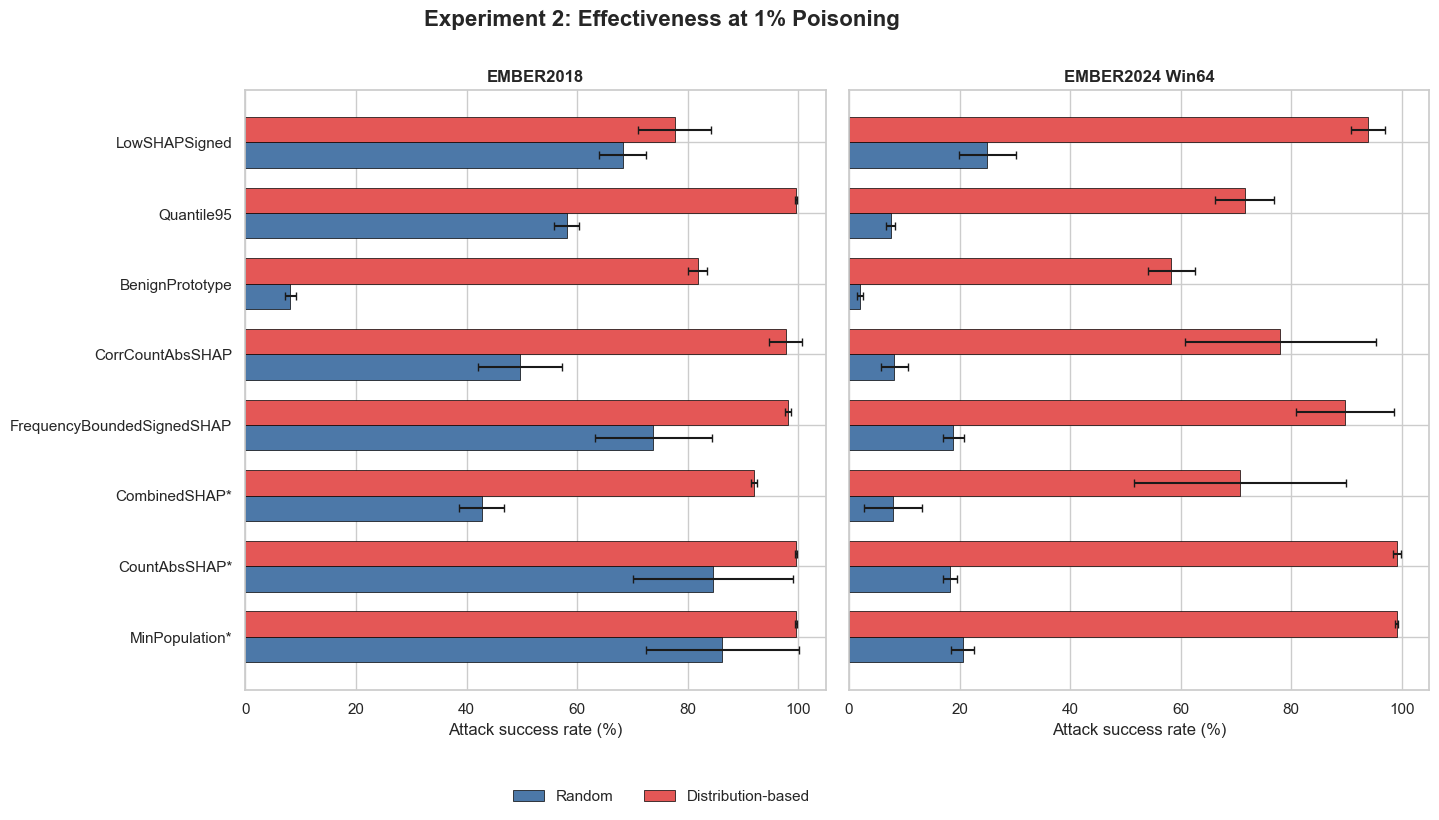

In [6]:
dataset_order = [value[0] for value in DATASETS.values()]
colors = {"Random": "#4C78A8", "Distribution-based": "#E45756"}
y = np.arange(len(SELECTOR_ORDER))
height = 0.36
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
fig.subplots_adjust(left=0.24, right=0.98, bottom=0.13, top=0.88, wspace=0.04)
for axis, dataset in zip(axes, dataset_order):
    subset = aggregate[aggregate.dataset == dataset]
    for index, sampling in enumerate(SAMPLING_ORDER):
        values = subset[subset.sampling == sampling].set_index("selector").reindex(SELECTOR_ORDER)
        offset = (index - 0.5) * height
        axis.barh(y + offset, values.asr_mean, height=height, xerr=values.asr_std,
                  capsize=3, label=sampling, color=colors[sampling],
                  edgecolor="black", linewidth=0.5)
    axis.set_title(dataset, fontweight="bold")
    axis.set_xlabel("Attack success rate (%)")
    axis.set_xlim(0, 105)
    axis.set_yticks(y, SELECTOR_ORDER)
    axis.invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Experiment 2: Effectiveness at 1% Poisoning", fontsize=16, fontweight="bold")
for suffix in ("png", "pdf"):
    fig.savefig(FIGURES / f"effectiveness_asr_mean_std.{suffix}", dpi=300, bbox_inches="tight")
plt.show()

## Clean-Accuracy Change

The change is backdoored clean accuracy minus seed-matched original clean accuracy, in percentage points. Values near zero indicate little clean-accuracy cost.

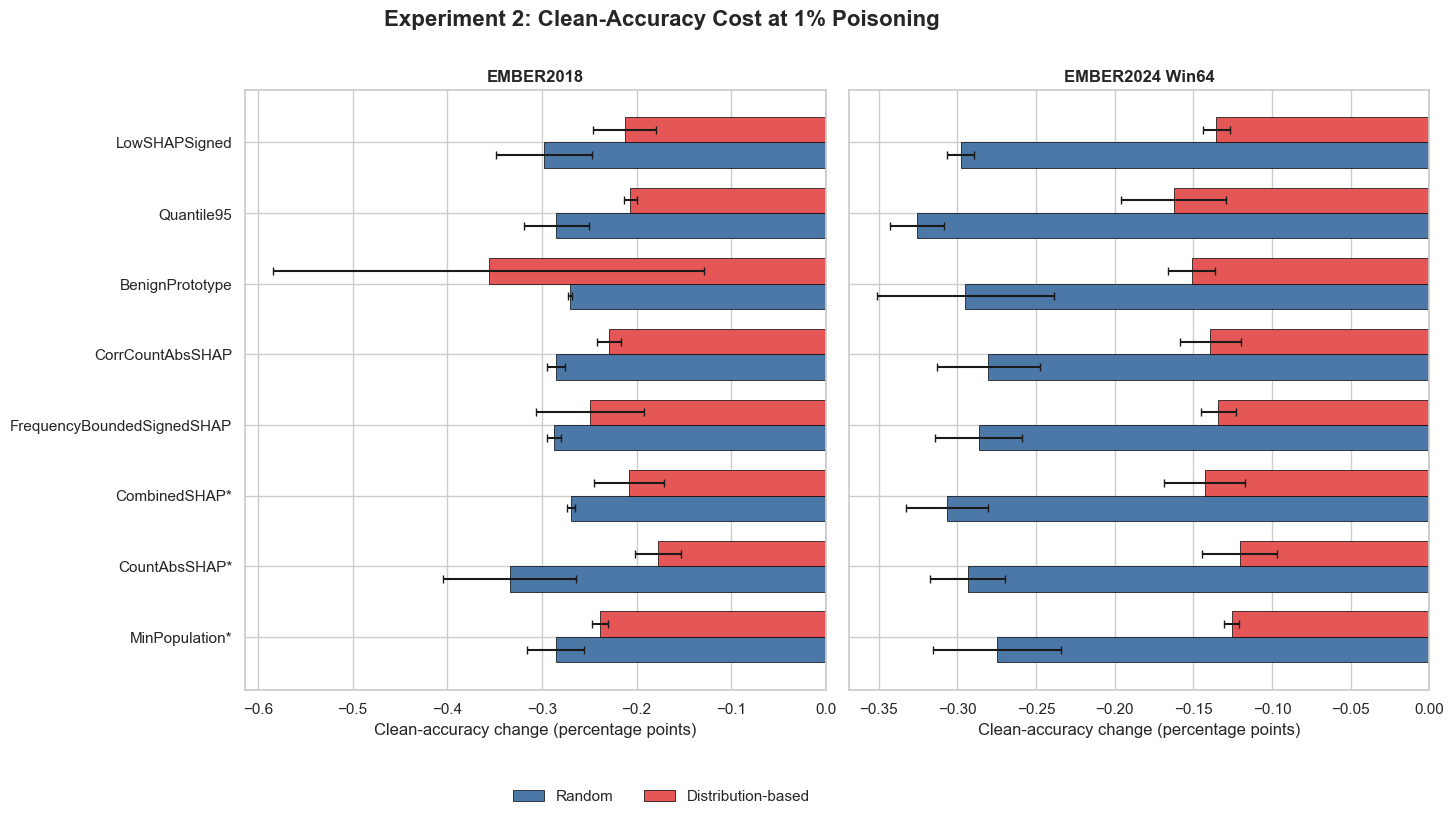

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
fig.subplots_adjust(left=0.24, right=0.98, bottom=0.13, top=0.88, wspace=0.04)
for axis, dataset in zip(axes, dataset_order):
    subset = aggregate[aggregate.dataset == dataset]
    for index, sampling in enumerate(SAMPLING_ORDER):
        values = subset[subset.sampling == sampling].set_index("selector").reindex(SELECTOR_ORDER)
        offset = (index - 0.5) * height
        axis.barh(y + offset, values.clean_delta_mean, height=height,
                  xerr=values.clean_delta_std, capsize=3, label=sampling,
                  color=colors[sampling], edgecolor="black", linewidth=0.5)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(dataset, fontweight="bold")
    axis.set_xlabel("Clean-accuracy change (percentage points)")
    axis.set_yticks(y, SELECTOR_ORDER)
    axis.invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Experiment 2: Clean-Accuracy Cost at 1% Poisoning", fontsize=16, fontweight="bold")
for suffix in ("png", "pdf"):
    fig.savefig(FIGURES / f"effectiveness_clean_accuracy_delta_mean_std.{suffix}", dpi=300, bbox_inches="tight")
plt.show()

## Export Validated Tables

In [8]:
paths = {
    "seed-level": EXPORTS / "effectiveness_seed_level.csv",
    "numeric aggregate": EXPORTS / "effectiveness_seed_aggregate.csv",
    "mean-SD table": EXPORTS / "effectiveness_mean_std_table.csv",
    "audit": EXPORTS / "effectiveness_audit.json",
}
seed_table.to_csv(paths["seed-level"], index=False)
aggregate.to_csv(paths["numeric aggregate"], index=False)
paper.to_csv(paths["mean-SD table"], index=False)
paths["audit"].write_text(json.dumps({**audit, "excluded_extra_paths": extras}, indent=2) + "\n")
for label, path in paths.items():
    print(f"{label}: {path}")

seed-level: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_2/results/exports/effectiveness_seed_level.csv
numeric aggregate: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_2/results/exports/effectiveness_seed_aggregate.csv
mean-SD table: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_2/results/exports/effectiveness_mean_std_table.csv
audit: /Users/falcon/Machine Learning/Defense GMM-Maha/notebooks/experiment_2/results/exports/effectiveness_audit.json


* indicates a Severi-derived selector. ASR is the fraction of triggered malware samples classified as benign by the backdoored model.